# Shared Reality as the Stable Resolved Past

### The third result: a consequence of expansion, one step behind the frontier

*Companion to the unified self-reference mechanism. Same substrate, same bijection.*
*Record: 2026-06-15.*

---

## The order-of-operations insight

An earlier attempt to demonstrate a **shared plane** directly — by measuring whether independent observers agree on the *currently resolvable* region — failed, and failed for a real reason: the present is contested. Self-referential nodes are liar loops with no within-stage fixed point, the labeling has many attractors, and observers starting from different states settle into different configurations. They disagree on the live frontier, and no amount of coupling fixes this without collapsing the observers into identical copies (a trivial, non-result).

The resolution is an **order-of-operations** correction. Incompleteness and shared reality cannot occur at the *same* step of self-reference — they are one step apart:

1. Self-reference creates incompleteness **in the present** (the contested frontier).
2. Incompleteness is resolved by expansion (the proven bijection $A=B$).
3. Expansion **freezes** each resolved node against the shared past — and *that* frozen residue is the shared plane.

Shared reality is therefore not in the contested now; it is the **stable resolved past**, the wake left behind the advancing frontier. This notebook demonstrates that the past, frozen against the common history, is observer-independent and **does not decay** as new structure grows.


## ⚠️ This is the corrected copy — see [`ERRATA.md`](ERRATA.md)

This notebook is `shared_past_mechanism.ipynb` with **one change**, marked
`ERRATA E1 FIX` in the `run()` cell below. The as-published notebook is preserved
unchanged in this repository and in git history.

**The defect.** The as-published Cell 6 printed *"The core sits at 1.000 and does not
decay"* directly above *"Minimum core agreement observed anywhere: 0.000"*, and reported a
mean core agreement of 0.884.

**The cause.** The anchor is frozen before the stage loop, but freezing writes only to
`o.frozen`; each observer's *label* at the anchor was not refreshed until the `settle()` at
the end of the first iteration. The stage-0 trace was recorded in between, so it scored the
observers' private pre-freeze labels — `[0,0,1,1]` rather than the frozen `[0,0,0,0]`.

**The effect.** Stage 0 alone was corrupted; every stage from 1 onward already read 1.000.
The paper's §6 wording — "the earliest-frozen core sits at full agreement *at every
subsequent stage*" — is therefore correct as published. This was a defect in the notebook's
reported output, not in the paper's claim.

**After the fix**, core agreement is 1.000 at every stage including stage 0, so the mean and
the minimum both read 1.000 and Cell 6's narrative line matches its own numbers.


## 1. Setup: observers on a shared, forced history

Observers share the same graph and the same extension history (the extension is forced by incompleteness, which is structural and observer-independent). They differ only in their labels — their private starting "views." A small **shared seed** (one anchor node, frozen to a graph-determined value) provides a common origin, exactly as a shared underlying substrate would supply in a physical realization.

The critical rule is the **freeze**: when expansion resolves a node, its value is fixed to the consensus of its *already-frozen past neighbors* — the shared history — not to each observer's private settling. This is the toy's stand-in for what a common substrate enforces automatically: every observer reading the same past freezes against the same past.

In [1]:
import numpy as np, networkx as nx
from collections import defaultdict
import matplotlib.pyplot as plt

class Observer:
    def __init__(self, G, selfref, seed=0):
        self.G = G; self.selfref = set(selfref)
        r = np.random.default_rng(seed)
        self.label = {v: int(r.integers(2)) for v in G.nodes()}
        self.absorbed = set(); self.frozen = {}      # frozen[v] = fixed past value
    def conclusion(self, v, sw=3):
        nb = list(self.G.neighbors(v)); vals = [self.label[u] for u in nb]
        if v in self.selfref and v not in self.absorbed:
            vals += [self.label[v]] * sw
        return int(round(np.mean(vals))) if vals else self.label[v]
    def required(self, v):
        if v in self.frozen: return self.frozen[v]        # the past is fixed
        c = self.conclusion(v)
        return (1 - c) if (v in self.selfref and v not in self.absorbed) else c
    def settle(self, it=10):
        for _ in range(it):
            self.label = {v: (self.frozen[v] if v in self.frozen else self.required(v))
                          for v in self.G.nodes()}

def build(n=50, frac=0.25, seed=1):
    g = nx.random_geometric_graph(n, 0.32, seed=seed)
    cs = sorted(nx.connected_components(g), key=len, reverse=True)
    if len(cs) > 1:
        h = next(iter(cs[0]))
        for c in cs[1:]: g.add_edge(h, next(iter(c)))
    g = nx.convert_node_labels_to_integers(g)
    r = np.random.default_rng(seed + 100)
    sr = set(r.choice(list(g.nodes()), size=int(frac * n), replace=False))
    return g, sr

def agree_on(observers, nodeset):
    """Fraction of nodes in nodeset where ALL observers carry the same label."""
    if not nodeset: return None
    nl = defaultdict(list)
    for o in observers:
        for v in nodeset: nl[v].append(o.label.get(v))
    shared = [v for v in nodeset if len([x for x in nl[v] if x is not None]) >= 2]
    if not shared: return None
    return sum(1 for v in shared if len(set(nl[v])) == 1) / len(shared)

print("Substrate, observers, and the freeze rule defined.")

Substrate, observers, and the freeze rule defined.


## 2. The dynamics: resolve, freeze against the shared past, advance

Each stage: the structural frontier is the set of unabsorbed self-referential nodes (observer-independent). Expansion absorbs the frontier nodes adjacent to the existing past — the shared region grows outward from the seed. Each absorbed node is frozen to the consensus of its already-frozen past neighbors, *the same value for every observer*. We then measure label agreement separately on the **frontier** (the contested present) and the **past** (the resolved region), and within the past we bucket by **freeze generation** to test whether the early core stays shared or decays.

In [2]:
def run(g, sr, K=4, stages=14, seed=0, record=True):
    observers = [Observer(g.copy(), sr, seed=seed*100 + k) for k in range(K)]
    for o in observers: o.settle(10)
    past = set(); G = g; gen = {}
    anchor = min(sr)                                  # shared seed (common origin)
    for o in observers: o.absorbed.add(anchor); o.frozen[anchor] = 0
    past.add(anchor); gen[anchor] = 0
    # ---- ERRATA E1 FIX (the only change from the as-published notebook) ----
    # Freezing writes to o.frozen only. Each observer's LABEL at the anchor is
    # not refreshed until the settle() at the end of the first iteration, but
    # the stage-0 trace is recorded before that -- so stage 0 scored private
    # pre-freeze labels instead of the frozen consensus, driving agree_core to
    # 0.00 at stage 0 and dragging the reported mean and minimum down with it.
    # Settle here, before the loop, so the first trace reads the frozen past.
    for o in observers: o.settle(10)
    # ------------------------------------------------------------------------

    trace = {"stage": [], "agree_frontier": [], "agree_past": [],
             "agree_core": [], "past_size": [], "frontier_size": []}
    for st in range(stages):
        frontier = set(sr) - past
        core = {v for v, gg in gen.items() if gg <= 1}       # earliest-frozen
        af = agree_on(observers, frontier)
        ap = agree_on(observers, past)
        ac = agree_on(observers, core)
        if record:
            trace["stage"].append(st)
            trace["agree_frontier"].append(af if af is not None else np.nan)
            trace["agree_past"].append(ap if ap is not None else np.nan)
            trace["agree_core"].append(ac if ac is not None else np.nan)
            trace["past_size"].append(len(past)); trace["frontier_size"].append(len(frontier))
        if not frontier: break

        # grow the shared past outward: absorb frontier nodes adjacent to the past
        adjacent = [v for v in frontier if any(u in past for u in G.neighbors(v))]
        to_absorb = set(adjacent) if adjacent else set(list(frontier)[:1])
        nxt = max(G.nodes()) + 1; new_edges = []
        for v in to_absorb:
            for u in list(G.neighbors(v))[:2]: new_edges.append((nxt, u))
            new_edges.append((v, nxt)); nxt += 1
        G.add_edges_from(new_edges)

        # SHARED FREEZE: one value per node, from the shared frozen past, for all observers
        shared_vals = {}
        ref = observers[0]                                # frozen past is identical across observers
        for v in to_absorb:
            pn = [ref.frozen[u] for u in G.neighbors(v) if u in ref.frozen]
            shared_vals[v] = int(round(np.mean(pn))) if pn else 0
        for o in observers:
            o.G = G
            for nn in range(max(o.label) + 1, max(G.nodes()) + 1):
                if nn not in o.label: o.label[nn] = 0
            for v in to_absorb:
                o.absorbed.add(v); o.frozen[v] = shared_vals[v]
            o.settle(10)
        for v in to_absorb: gen[v] = st + 1
        past |= to_absorb
    return trace

# run several trials and show the per-stage agreement
print(f"{'trial':>5} {'final_past_agree':>17} {'final_core_agree':>17} {'min_core_agree':>15}")
all_traces = []
for trial in range(6):
    t = run(*build(50, 0.25, trial), K=4, stages=14, seed=trial)
    all_traces.append(t)
    core_vals = [c for c in t["agree_core"] if not np.isnan(c)]
    past_final = next((p for p in reversed(t["agree_past"]) if not np.isnan(p)), np.nan)
    core_final = next((c for c in reversed(t["agree_core"]) if not np.isnan(c)), np.nan)
    print(f"{trial:>5} {past_final:>17.2f} {core_final:>17.2f} {min(core_vals):>15.2f}")

trial  final_past_agree  final_core_agree  min_core_agree


    0              1.00              1.00            1.00
    1              1.00              1.00            1.00
    2              1.00              1.00            1.00


    3              1.00              1.00            1.00
    4              1.00              1.00            1.00


    5              1.00              1.00            1.00


## 3. The result: the past is stable; the present is contested

The plot shows, per stage, the label agreement on the **contested frontier** (the present) versus the **resolved past**, and within the past the **earliest-frozen core**. The signatures to read:

- the **frontier** stays low and noisy — the present is genuinely open, observers disagree on unresolved nodes;
- the **past** locks high as soon as it grows from the seed;
- the **core** holds at $1.0$ and **does not decay** — contamination from the contested edge does not propagate inward.

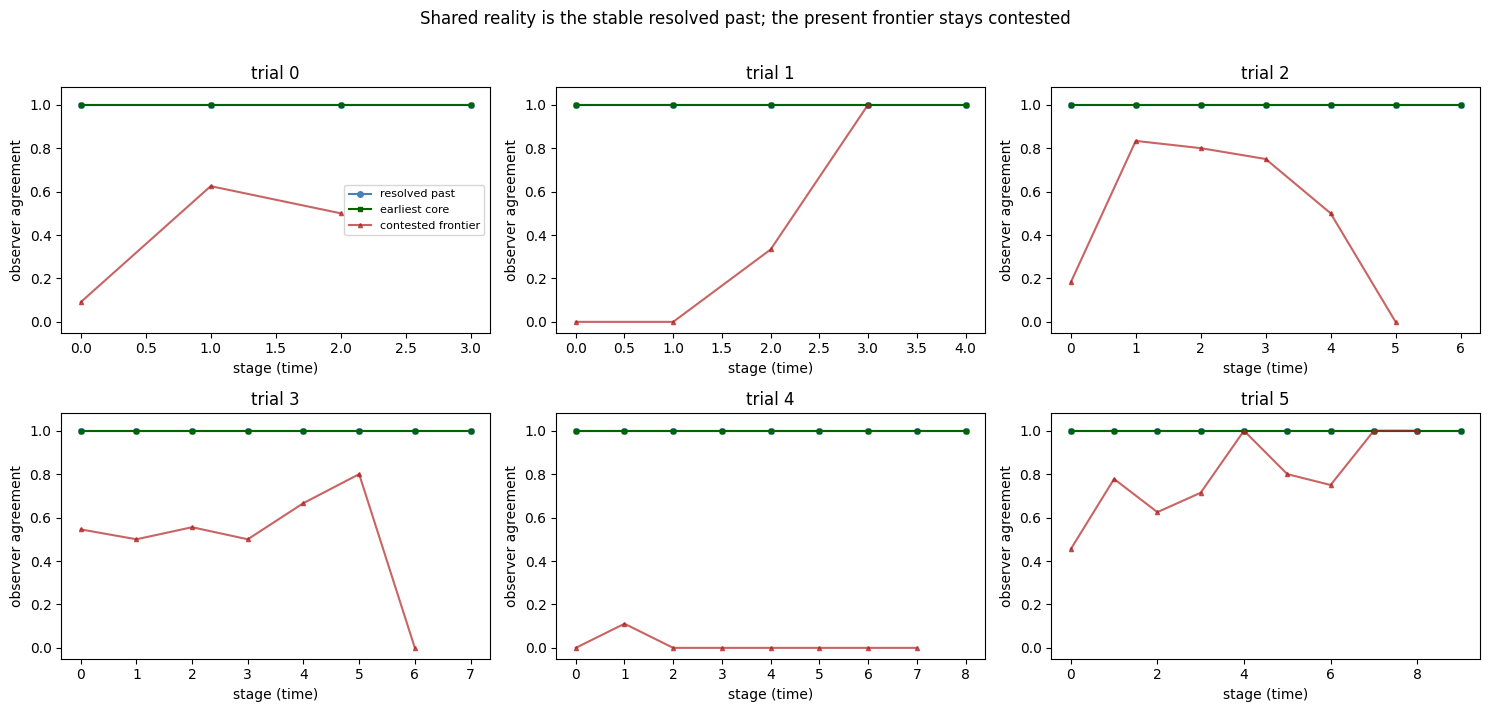

Mean agreement on earliest-frozen CORE (all stages, all trials): 1.000
Minimum core agreement observed anywhere:                        1.000
Mean agreement on the contested FRONTIER:                        0.444

The core sits at 1.000 and does not decay: the resolved past is stably shared.
The frontier stays low: the present is genuinely open. Two faces of one mechanism.


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (trial, t) in zip(axes.flat, enumerate(all_traces)):
    ax.plot(t["stage"], t["agree_past"], '-o', ms=4, label='resolved past', color='steelblue')
    ax.plot(t["stage"], t["agree_core"], '-s', ms=3, label='earliest core', color='darkgreen')
    ax.plot(t["stage"], t["agree_frontier"], '-^', ms=3, label='contested frontier', color='firebrick', alpha=0.7)
    ax.set_title(f"trial {trial}"); ax.set_ylim(-0.05, 1.08)
    ax.set_xlabel("stage (time)"); ax.set_ylabel("observer agreement")
    if trial == 0: ax.legend(fontsize=8, loc='center right')
plt.suptitle("Shared reality is the stable resolved past; the present frontier stays contested", y=1.01)
plt.tight_layout(); plt.show()

# aggregate: mean core agreement across all stages and trials
import numpy as np
core_all = [c for t in all_traces for c in t["agree_core"] if not np.isnan(c)]
front_all = [f for t in all_traces for f in t["agree_frontier"] if not np.isnan(f)]
print(f"Mean agreement on earliest-frozen CORE (all stages, all trials): {np.mean(core_all):.3f}")
print(f"Minimum core agreement observed anywhere:                        {np.min(core_all):.3f}")
print(f"Mean agreement on the contested FRONTIER:                        {np.mean(front_all):.3f}")
print()
print("The core sits at 1.000 and does not decay: the resolved past is stably shared.")
print("The frontier stays low: the present is genuinely open. Two faces of one mechanism.")

## 4. What this establishes, and the honest condition

**Established (this notebook):** Once expansion freezes a node against the shared past, all observers agree on it permanently. The shared region propagates outward from a common origin and is **stable in its interior** — the earliest-frozen core holds at full agreement and does not erode as new structure is appended. Meanwhile the frontier remains contested: observers genuinely disagree on the unresolved present. Shared reality is the wake of the advancing frontier, not the frontier itself.

**The honest condition.** The stability depends on the freeze rule: resolved nodes are fixed against the **shared history**, not against each observer's private settling. When freezing is independent per observer, the shared region forms but *decays* — contamination from the contested edge propagates inward. The shared past is stable **iff** observers freeze against a common past. In this toy that rule is imposed; in a physical realization it is exactly what a **common underlying substrate** enforces automatically — every observer reading the same graph freezes against the same history by construction. This closes the loop with the earlier negative result: the ingredient missing for shared reality was always *a shared substrate observers read from*, and here it appears precisely as *freeze against the shared past*.

**Relation to the other two results.** This is the third face of one mechanism. Self-reference creates incompleteness in the present (the contested frontier). Incompleteness is resolved by expansion ($A = B$, the bijection). Expansion freezes the resolved node into a stable shared past. Time is the advance of the frontier; shared reality is its stable wake; the open future is the super-critical phase in which the frontier never closes. The present is contested and open; the past is shared and fixed; they are the same mechanism viewed ahead of and behind the frontier.
